In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove missing values
df.dropna(inplace=True)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Dataset overview
print(df.head())
print(df.describe())

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
                             Date  Estimated Unemployment Rate (%)  \
count                         740              

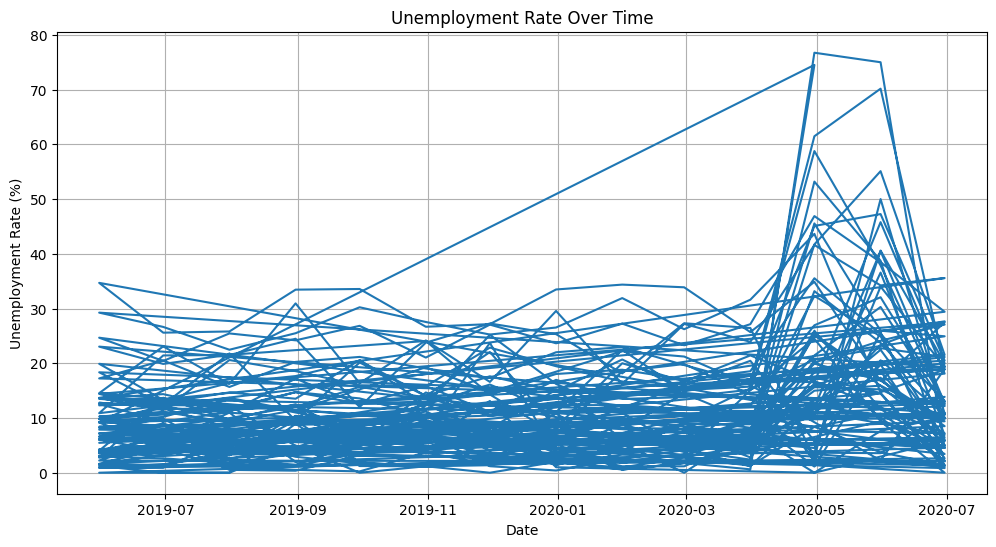

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Estimated Unemployment Rate (%)"])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()


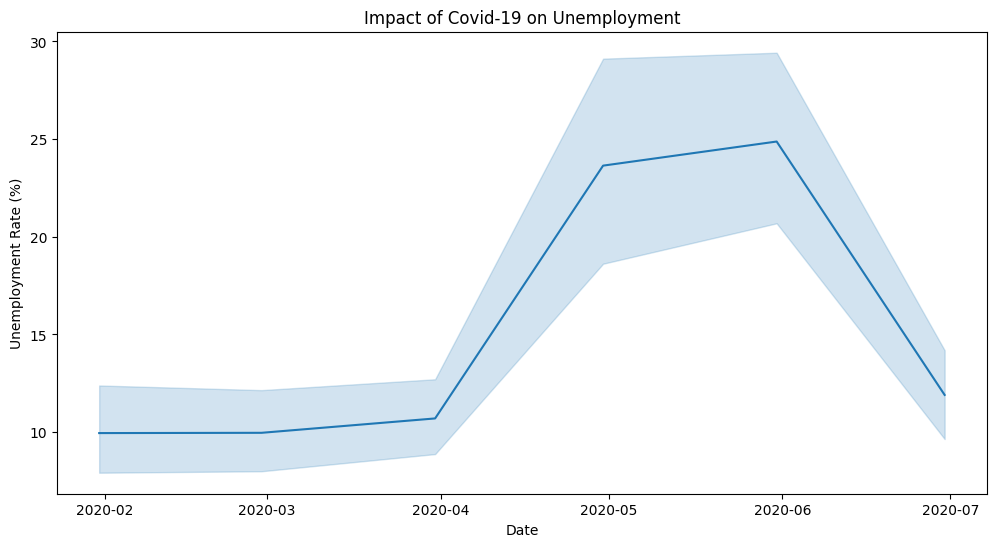

In [18]:
covid = df[df["Date"].dt.year == 2020]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)
plt.title("Impact of Covid-19 on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

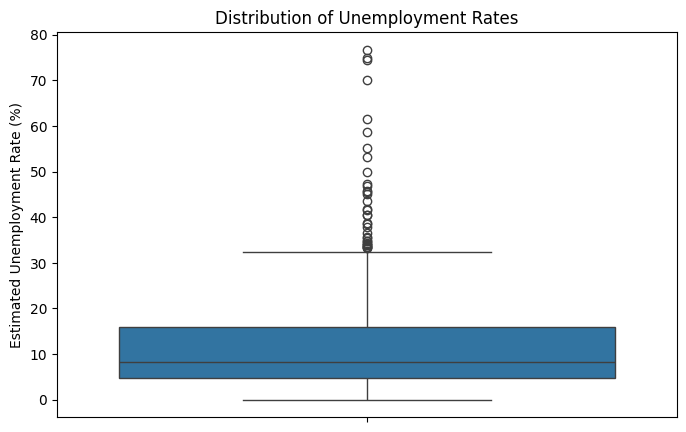

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Estimated Unemployment Rate (%)"])
plt.title("Distribution of Unemployment Rates")
plt.show()



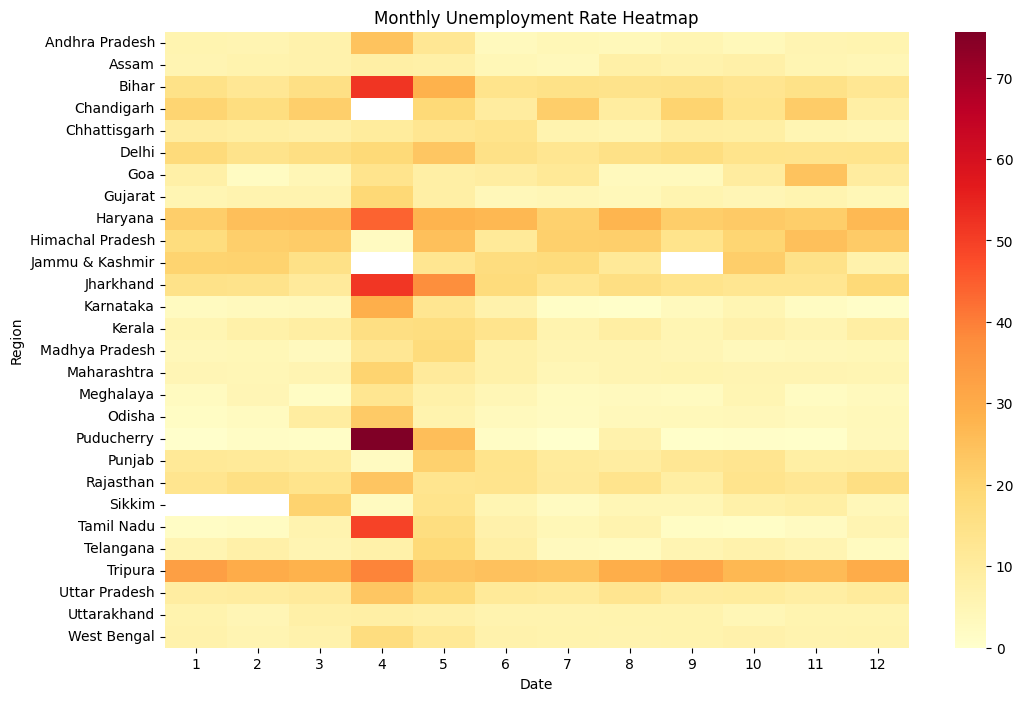

In [20]:
pivot = df.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Region",
    columns=df["Date"].dt.month,
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Monthly Unemployment Rate Heatmap")
plt.show()


In [23]:
avg_region = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

highest_region = avg_region.idxmax()
lowest_region = avg_region.idxmin()

print("Highest Average Unemployment Region:", highest_region)
print("Rate:", round(avg_region.max(), 2), "%")

print("Lowest Average Unemployment Region:", lowest_region)
print("Rate:", round(avg_region.min(), 2), "%")

Highest Average Unemployment Region: Tripura
Rate: 28.35 %
Lowest Average Unemployment Region: Meghalaya
Rate: 4.8 %
